In [3]:
import pandas as pd
df = pd.read_csv("../Data/Raw/AB_US_2020.csv", low_memory=False)

df.shape          # rows, columns
df.head()         # first 5 rows — sanity check the data "looks like" what we expect
df.info()         # dtypes and non-null counts
df.describe()     # numeric summary stats — mean, min, max, quartiles

<class 'pandas.DataFrame'>
RangeIndex: 226030 entries, 0 to 226029
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              226030 non-null  int64  
 1   name                            226002 non-null  str    
 2   host_id                         226030 non-null  int64  
 3   host_name                       225997 non-null  str    
 4   neighbourhood_group             110185 non-null  str    
 5   neighbourhood                   226030 non-null  str    
 6   latitude                        226030 non-null  float64
 7   longitude                       226030 non-null  float64
 8   room_type                       226030 non-null  str    
 9   price                           226030 non-null  int64  
 10  minimum_nights                  226030 non-null  int64  
 11  number_of_reviews               226030 non-null  int64  
 12  last_review                

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,2.260300e+05,2.260300e+05,226030.000000,226030.000000,226030.000000,2.260300e+05,226030.000000,177428.00000,226030.000000,226030.000000
mean,2.547176e+07,9.352385e+07,35.662829,-103.220662,219.716529,4.525490e+02,34.506530,1.43145,16.698562,159.314856
std,1.317814e+07,9.827422e+07,6.849855,26.222091,570.353609,2.103376e+05,63.602914,1.68321,51.068966,140.179628
min,1.090000e+02,2.300000e+01,18.920990,-159.714900,0.000000,1.000000e+00,0.000000,0.01000,1.000000,0.000000
25%,1.515890e+07,1.399275e+07,32.761783,-118.598115,75.000000,1.000000e+00,1.000000,0.23000,1.000000,0.000000
50%,2.590916e+07,5.138266e+07,37.261125,-97.817200,121.000000,2.000000e+00,8.000000,0.81000,2.000000,140.000000
75%,3.772624e+07,1.497179e+08,40.724038,-76.919323,201.000000,7.000000e+00,39.000000,2.06000,6.000000,311.000000
max,4.556085e+07,3.679176e+08,47.734620,-70.995950,24999.000000,1.000000e+08,966.000000,44.06000,593.000000,365.000000


In [4]:
df.duplicated().sum()              # exact duplicate rows


np.int64(0)

In [5]:
df['id'].duplicated().sum()        # duplicate listing IDs — should be 0, since id is a primary key

np.int64(1)

In [6]:
df.isnull().sum().sort_values(ascending=False)
(df.isnull().sum() / len(df) * 100).round(2)   # missing as a percentage — easier to interpret

id                                 0.00
name                               0.01
host_id                            0.00
host_name                          0.01
neighbourhood_group               51.25
neighbourhood                      0.00
latitude                           0.00
longitude                          0.00
room_type                          0.00
price                              0.00
minimum_nights                     0.00
number_of_reviews                  0.00
last_review                       21.50
reviews_per_month                 21.50
calculated_host_listings_count     0.00
availability_365                   0.00
city                               0.00
dtype: float64

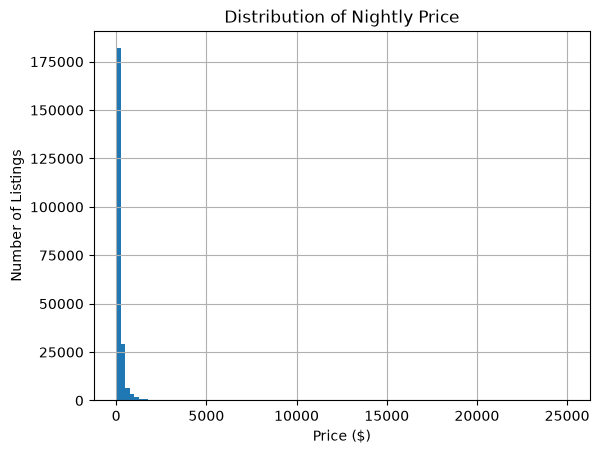

In [7]:
import matplotlib.pyplot as plt

df['price'].hist(bins=100)
plt.title("Distribution of Nightly Price")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")
plt.show()

In [8]:
print(df['price'].mean())
print(df['price'].median())

219.71652877936558
121.0


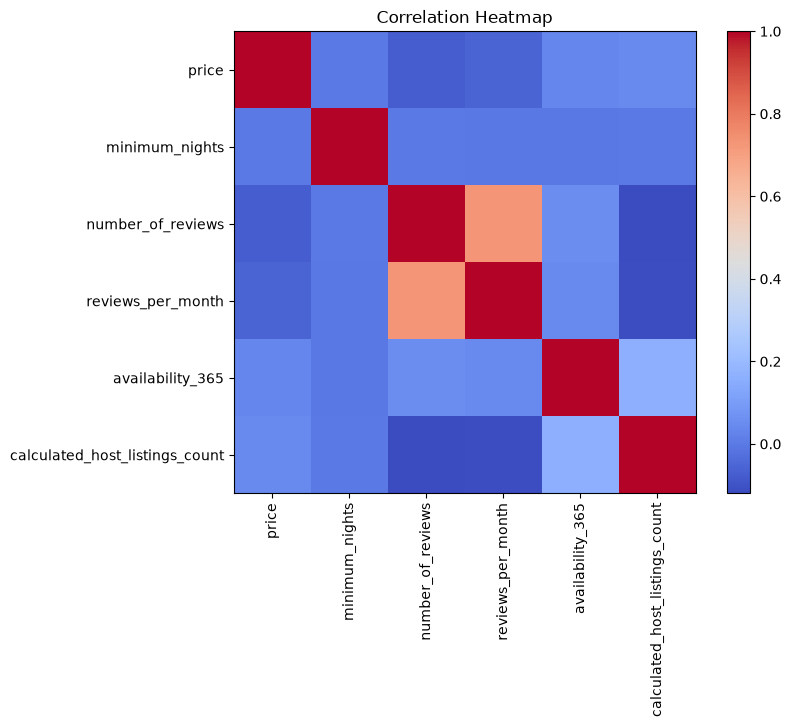

In [9]:
numeric_cols = ['price', 'minimum_nights', 'number_of_reviews', 
                 'reviews_per_month', 'availability_365', 'calculated_host_listings_count']
corr = df[numeric_cols].corr()

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Heatmap")
plt.show()